In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df= pd.read_csv('hotel_bookings.csv')

In [3]:
filter1 = (df["adults"]==0) & (df["children"]==0) & (df["babies"]==0)

In [4]:
print(df[filter1])

               hotel  is_canceled  lead_time  arrival_date_year  \
2224    Resort Hotel            0          1               2015   
2409    Resort Hotel            0          0               2015   
3181    Resort Hotel            0         36               2015   
3684    Resort Hotel            0        165               2015   
3708    Resort Hotel            0        165               2015   
...              ...          ...        ...                ...   
115029    City Hotel            0        107               2017   
115091    City Hotel            0          1               2017   
116251    City Hotel            0         44               2017   
116534    City Hotel            0          2               2017   
117087    City Hotel            0        170               2017   

       arrival_date_month  arrival_date_week_number  \
2224              October                        41   
2409              October                        42   
3181             November     

In [5]:
print(df[filter1].shape)

(180, 32)


In [6]:
df.shape

(119390, 32)

In [7]:
print(df[~filter1].shape)

(119210, 32)


In [8]:
df2 = df[~filter1]

In [9]:
df2.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
119385    False
119386    False
119387    False
119388    False
119389    False
Length: 119210, dtype: bool

In [10]:
df2.duplicated().sum()

np.int64(31980)

In [11]:
data = df2.drop_duplicates()

In [12]:
data.shape

(87230, 32)

In [13]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

In [14]:
print(data[['lead_time','total_of_special_requests', 'adr']].describe().T)

                             count        mean        std   min    25%   50%  \
lead_time                  87230.0   79.971019  86.058683  0.00  11.00  49.0   
total_of_special_requests  87230.0    0.698934   0.832051  0.00   0.00   0.0   
adr                        87230.0  106.518031  54.891227 -6.38  72.25  98.2   

                             75%     max  
lead_time                  125.0   737.0  
total_of_special_requests    1.0     5.0  
adr                        134.1  5400.0  


In [15]:
data.info()

<class 'pandas.DataFrame'>
Index: 87230 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87230 non-null  str    
 1   is_canceled                     87230 non-null  int64  
 2   lead_time                       87230 non-null  int64  
 3   arrival_date_year               87230 non-null  int64  
 4   arrival_date_month              87230 non-null  str    
 5   arrival_date_week_number        87230 non-null  int64  
 6   arrival_date_day_of_month       87230 non-null  int64  
 7   stays_in_weekend_nights         87230 non-null  int64  
 8   stays_in_week_nights            87230 non-null  int64  
 9   adults                          87230 non-null  int64  
 10  children                        87226 non-null  float64
 11  babies                          87230 non-null  int64  
 12  meal                            87230 non-null 

In [16]:
for col in ['lead_time' , 'total_of_special_requests' , 'adr']:
    print("feature_name : {}".format(col))

    for i in range(90,101,1):
        quantile_value = np.quantile(data[col], 1/100)
        print(" {}th quantile_value is {}".format(i, quantile_value))
    print('/n')

feature_name : lead_time
 90th quantile_value is 0.0
 91th quantile_value is 0.0
 92th quantile_value is 0.0
 93th quantile_value is 0.0
 94th quantile_value is 0.0
 95th quantile_value is 0.0
 96th quantile_value is 0.0
 97th quantile_value is 0.0
 98th quantile_value is 0.0
 99th quantile_value is 0.0
 100th quantile_value is 0.0
/n
feature_name : total_of_special_requests
 90th quantile_value is 0.0
 91th quantile_value is 0.0
 92th quantile_value is 0.0
 93th quantile_value is 0.0
 94th quantile_value is 0.0
 95th quantile_value is 0.0
 96th quantile_value is 0.0
 97th quantile_value is 0.0
 98th quantile_value is 0.0
 99th quantile_value is 0.0
 100th quantile_value is 0.0
/n
feature_name : adr
 90th quantile_value is 0.0
 91th quantile_value is 0.0
 92th quantile_value is 0.0
 93th quantile_value is 0.0
 94th quantile_value is 0.0
 95th quantile_value is 0.0
 96th quantile_value is 0.0
 97th quantile_value is 0.0
 98th quantile_value is 0.0
 99th quantile_value is 0.0
 100th quan

In [17]:
not_cancelled = data[data['is_canceled']==0]

In [18]:
print(not_cancelled.head(3))

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1                        0                     0       2  ...    No Deposit   
2                        0                     1       1  ...    No Deposit   

   agent company days_in_waiting_list customer_type   adr  \
0    NaN     NaN                    0     Transient   0.0   
1  

In [19]:
country_wise_data = not_cancelled['country'].value_counts().reset_index()

In [20]:
print(country_wise_data)

    country  count
0       PRT  17573
1       GBR   8440
2       FRA   7091
3       ESP   5382
4       DEU   4332
..      ...    ...
160     SDN      1
161     ATF      1
162     TJK      1
163     SLE      1
164     FRO      1

[165 rows x 2 columns]


In [21]:
country_wise_data.columns = ['country' , 'No of guests']

In [22]:
print(country_wise_data)

    country  No of guests
0       PRT         17573
1       GBR          8440
2       FRA          7091
3       ESP          5382
4       DEU          4332
..      ...           ...
160     SDN             1
161     ATF             1
162     TJK             1
163     SLE             1
164     FRO             1

[165 rows x 2 columns]


In [23]:
!pip install chart-studio
!pip install plotly


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [24]:
import chart_studio.plotly as py
import plotly.graph_objs as go
import plotly.express as px
from plotly.offline import download_plotlyjs , init_notebook_mode , plot , iplot
init_notebook_mode(connected=True)

In [25]:
map_guest = px.choropleth(data_frame=country_wise_data,
                         locations=country_wise_data['country'],
                          color=country_wise_data['No of guests'],
                          hover_name=country_wise_data['country'],
                          title= "Home Country Of Guests")

In [26]:
%pip install nbformat


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [39]:
import plotly.io as pio

# Keeps it safe for PyCharm, but others can change it if they want
pio.renderers.default = "browser"

map_guest.show()


In [46]:
pivot= pd.crosstab(index = data["reserved_room_type"], columns = data["assigned_room_type"], margins=True)

In [47]:
print(pivot)

assigned_room_type      A     B     C      D     E     F     G    H    I    K  \
reserved_room_type                                                              
A                   45850   892  1253   6402  1034   390   176   94  205  140   
B                     106   872     0      5     2     2     8    0    0    1   
C                       5     2   866      6     4     2    10    9   10    0   
D                     295    27    32  15979   657   199    82    9   67   29   
E                      15     2     6     22  5458   383    97    4   40    9   
F                       6    14     0      4    31  2636   113    3   10    3   
G                       5     1     2      0     4    14  1999    7   15    3   
H                       0     0     0      1     0     0    10  579    6    0   
L                       1     1     1      0     0     1     0    1    0    0   
All                 46283  1811  2160  22419  7190  3627  2495  706  353  185   

assigned_room_type  L    Al

In [51]:
pivot_normalize=pd.crosstab(index = data["reserved_room_type"], columns = data["assigned_room_type"], margins=True, normalize="index").round(2)*100
print(pivot_normalize)

assigned_room_type     A     B     C     D     E     F     G     H    I    K  \
reserved_room_type                                                             
A                   81.0   2.0   2.0  11.0   2.0   1.0   0.0   0.0  0.0  0.0   
B                   11.0  88.0   0.0   1.0   0.0   0.0   1.0   0.0  0.0  0.0   
C                    1.0   0.0  95.0   1.0   0.0   0.0   1.0   1.0  1.0  0.0   
D                    2.0   0.0   0.0  92.0   4.0   1.0   0.0   0.0  0.0  0.0   
E                    0.0   0.0   0.0   0.0  90.0   6.0   2.0   0.0  1.0  0.0   
F                    0.0   0.0   0.0   0.0   1.0  93.0   4.0   0.0  0.0  0.0   
G                    0.0   0.0   0.0   0.0   0.0   1.0  98.0   0.0  1.0  0.0   
H                    0.0   0.0   0.0   0.0   0.0   0.0   2.0  97.0  1.0  0.0   
L                   17.0  17.0  17.0   0.0   0.0  17.0   0.0  17.0  0.0  0.0   
All                 53.0   2.0   2.0  26.0   8.0   4.0   3.0   1.0  0.0  0.0   

assigned_room_type     L  
reserved_roo

In [53]:
data['market_segment'].value_counts()

market_segment
Online TA        51553
Offline TA/TO    13855
Direct           11780
Groups            4922
Corporate         4200
Complementary      692
Aviation           226
Undefined            2
Name: count, dtype: int64

In [54]:
data['market_segment'].value_counts().values

array([51553, 13855, 11780,  4922,  4200,   692,   226,     2])

In [55]:
data['market_segment'].value_counts().index

Index(['Online TA', 'Offline TA/TO', 'Direct', 'Groups', 'Corporate',
       'Complementary', 'Aviation', 'Undefined'],
      dtype='str', name='market_segment')

In [62]:
fig = px.pie(
       values = data['market_segment'].value_counts().values,
       names = data['market_segment'].value_counts().index)

In [64]:
fig.show()

In [65]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='str')

<Axes: xlabel='market_segment', ylabel='adr'>

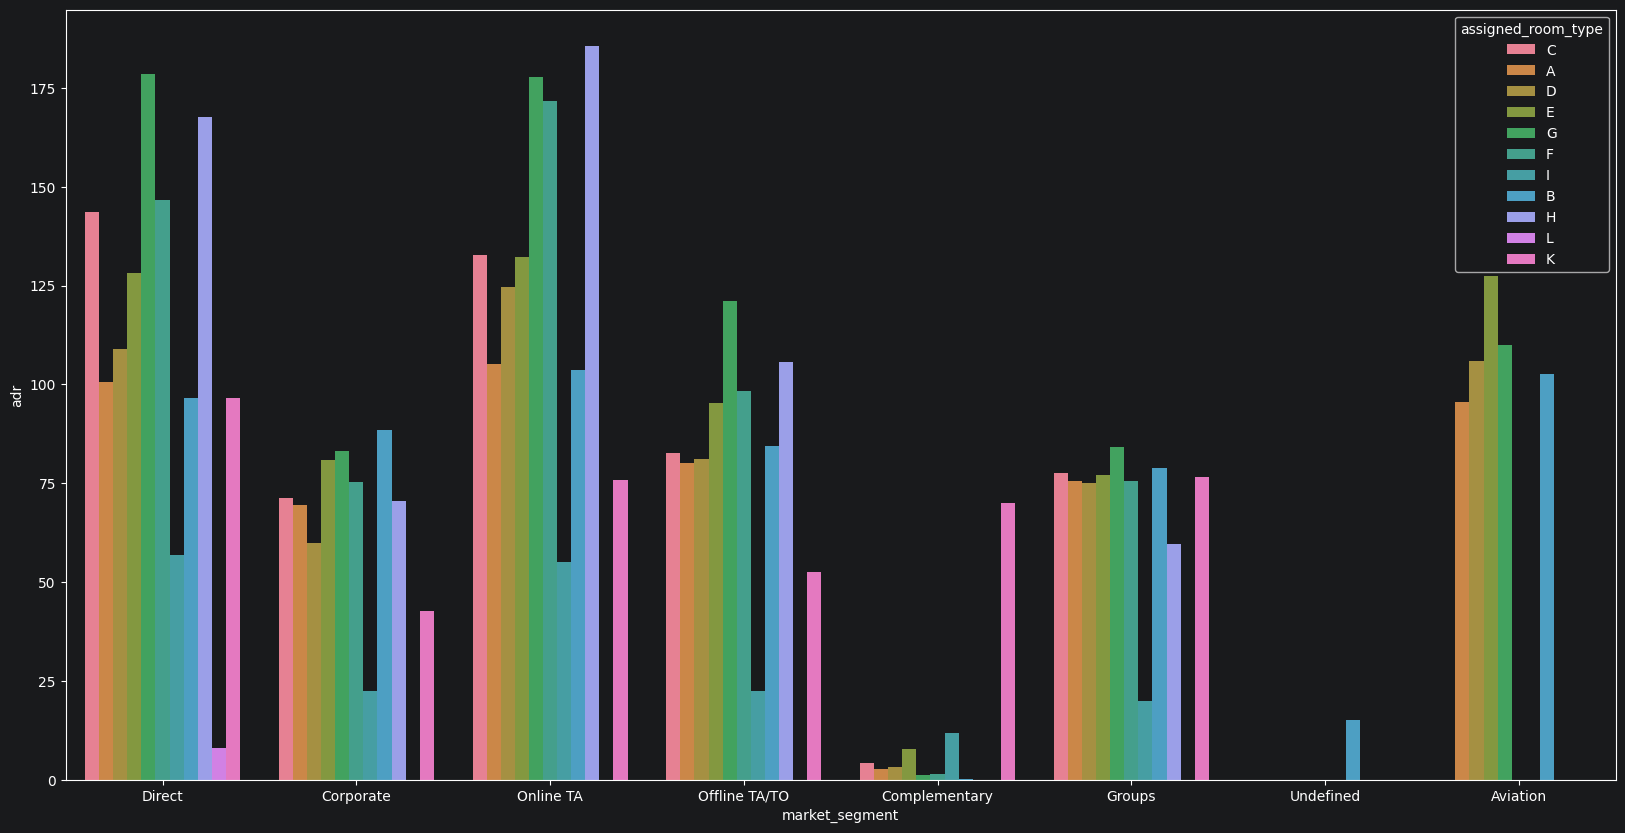

In [110]:
plt.figure(figsize=(20,10))
sns.barplot(x="market_segment", y="adr",hue="assigned_room_type", data=data,errorbar=None)

In [69]:
data['arrival_date_month'].unique()

<StringArray>
[     'July',    'August', 'September',   'October',  'November',  'December',
   'January',  'February',     'March',     'April',       'May',      'June']
Length: 12, dtype: str

In [71]:
dict_month = {   'July':7,    'August':8, 'September':9,   'October':10,  'November':11,  'December':12,
   'January':1,  'February':2,     'March':3,     'April':4,       'May':5,      'June':6}

In [73]:
data['arrival_date_month_index'] = data['arrival_date_month'].map(dict_month)

In [77]:
print(data[['arrival_date_year', 'arrival_date_month_index','arrival_date_day_of_month']])

        arrival_date_year  arrival_date_month_index  arrival_date_day_of_month
0                    2015                         7                          1
1                    2015                         7                          1
2                    2015                         7                          1
3                    2015                         7                          1
4                    2015                         7                          1
...                   ...                       ...                        ...
119385               2017                         8                         30
119386               2017                         8                         31
119387               2017                         8                         31
119388               2017                         8                         31
119389               2017                         8                         29

[87230 rows x 3 columns]


In [81]:
data['arrival_date'] = data['arrival_date_year'].astype(str)  + '-' + data["arrival_date_month_index"].astype(str) + '-' + data['arrival_date_day_of_month'].astype(str)

In [83]:
print(data.head(3))

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  company  \
0                        0                     0       2  ...      NaN   
1                        0                     0       2  ...      NaN   
2                        0                     1       1  ...      NaN   

   days_in_waiting_list customer_type   adr required_car_parking_spaces  \
0                     0     Transient   0.0                           

In [84]:
data.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date',
       'arrival_date_month_index', 'arrival_date'],
      dtype='str')

In [88]:
data[['adults', 'children', 'babies']]

,adults,children,babies
0,2,0.0,0
1,2,0.0,0
2,1,0.0,0
3,1,0.0,0
4,2,0.0,0
...,...,...,...
119385,2,0.0,0
119386,3,0.0,0
119387,2,0.0,0
119388,2,0.0,0


In [91]:
data["Total_guests"] = data["adults"] + data["children"] + data["babies"]

In [92]:
print(data.head(2))

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  \
0                        0                     0       2  ...   
1                        0                     0       2  ...   

   days_in_waiting_list  customer_type  adr required_car_parking_spaces  \
0                     0      Transient  0.0                           0   
1                     0      Transient  0.0                           0   

  total_of_special_requests reservation_status  reservation_status_date  \
0                         0          Check-Out                 7/1/2015   
1        

In [94]:
print(data[['arrival_date','Total_guests']])

       arrival_date  Total_guests
0          2015-7-1           2.0
1          2015-7-1           2.0
2          2015-7-1           1.0
3          2015-7-1           1.0
4          2015-7-1           2.0
...             ...           ...
119385    2017-8-30           2.0
119386    2017-8-31           3.0
119387    2017-8-31           2.0
119388    2017-8-31           2.0
119389    2017-8-29           2.0

[87230 rows x 2 columns]


In [97]:
dataNoCancel = data[data['is_canceled']==0]

In [101]:
guest_arrival_series = dataNoCancel.groupby(['arrival_date'])['Total_guests'].sum()

<Axes: xlabel='arrival_date'>

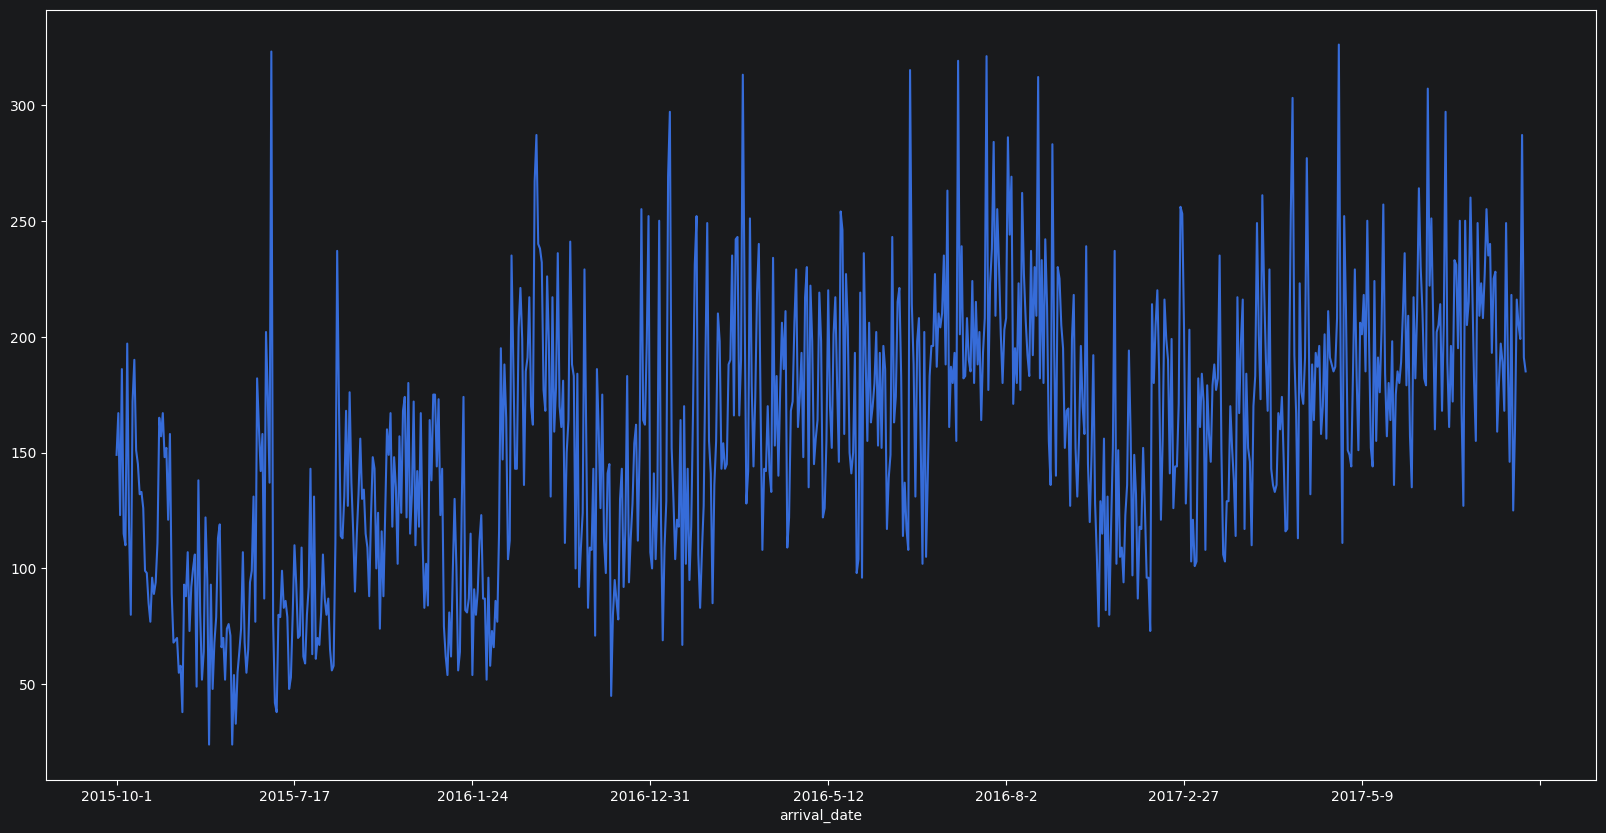

In [111]:
guest_arrival_series.plot(figsize=(20,10))

In [112]:
print(guest_arrival_series)

arrival_date
2015-10-1     149.0
2015-10-10    167.0
2015-10-11    123.0
2015-10-12    186.0
2015-10-13    115.0
              ...  
2017-8-5      205.0
2017-8-6      199.0
2017-8-7      287.0
2017-8-8      191.0
2017-8-9      185.0
Name: Total_guests, Length: 793, dtype: float64


In [115]:
print(type(guest_arrival_series))

<class 'pandas.Series'>


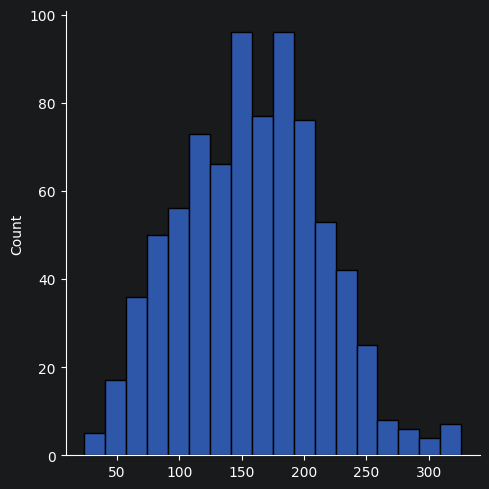

In [114]:
sns.displot(guest_arrival_series.values)

In [116]:
np.mean(guest_arrival_series.values)

np.float64(157.92559899117276)

In [117]:
np.median(guest_arrival_series.values)

np.float64(158.0)

In [118]:
np.std(guest_arrival_series.values)

np.float64(56.48263702610786)